## EN3160-Fundamentals of Image Processing and Computer Vision

## Assignment 01 - <br> Intensity Transformations and Neighborhood Filtering

**Name:** Bandara H.Y.W.  <br>
**Index Number:** 230074J <br>
**GitHub:** 

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show_bgr(ax, img, title):
    ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

### Question 1 - Piecewise Linear Intensity Transformation

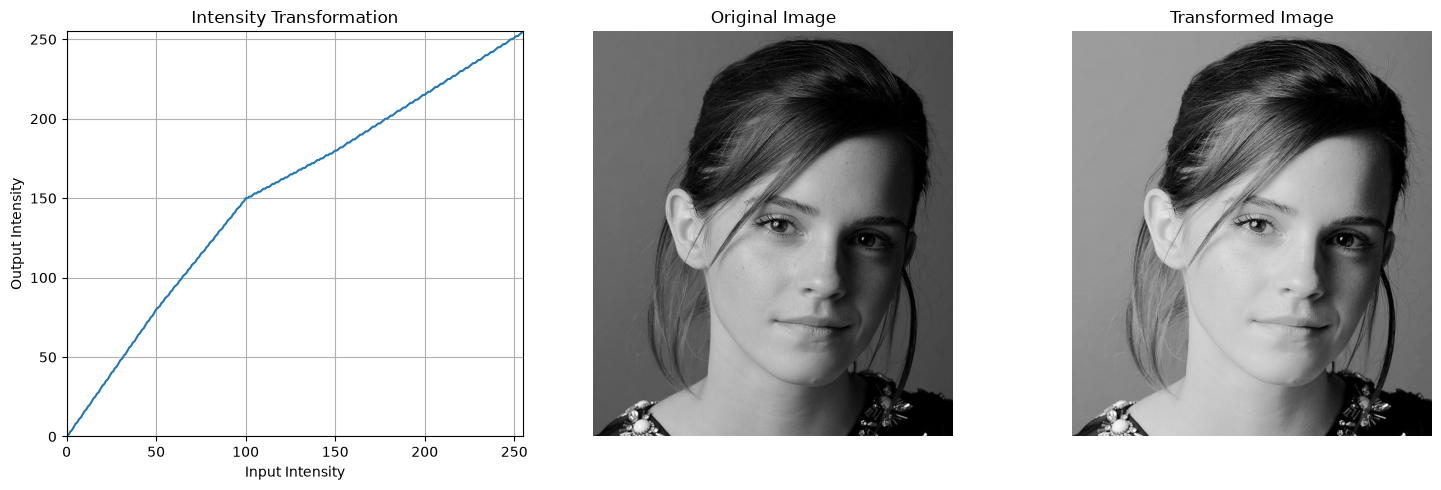

In [19]:
im = cv.imread('images/fig1b_intensity_image.jpg',cv.IMREAD_GRAYSCALE)

assert im is not None, "Image could not be loaded."

def intensity_transform(im, breakpoints):

    bp = np.asarray(breakpoints, dtype=np.float32)

    x = bp[:, 0]
    y = bp[:, 1]

    lut = np.zeros(256, dtype=np.float32)

    for r in range(256):

        if r <= x[0]:
            lut[r] = y[0]

        elif r >= x[-1]:
            lut[r] = y[-1]

        else:
            k = np.searchsorted(x, r, side='right') - 1

            x1 = x[k];     y1 = y[k]
            x2 = x[k + 1]; y2 = y[k + 1]
            
            lut[r] = y1 + ((r-x1)*(y2-y1)/(x2-x1))

    lut = np.clip(lut,0,255).astype(np.uint8)
    transformed = cv.LUT(im, lut)

    return transformed, lut


breakpoints = np.array([
    [0,   0],
    [50,  80],
    [100, 150],
    [150, 180],
    [255, 255]
])



transformed, lut = intensity_transform(im,breakpoints)


fig, ax = plt.subplots(1,3,figsize=(15, 5))



ax[0].plot(np.arange(256),lut)
ax[0].set_title('Intensity Transformation')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim(0,255)
ax[0].set_ylim(0,255)
ax[0].grid()

ax[1].imshow(im,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()


